# **Prediksi Konversi Pengunjung E-Commerce Berdasarkan Perilaku Browsing Customer**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score,
    ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

df.info()
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print(df.columns.tolist())
df.describe(include="all").T
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Exploratory Data Analysis (EDA)

### A. Cek Missing Value

In [3]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Value": missing,
    "Persentase (%)": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Value,Persentase (%)
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


### B. Cek Duplikat

In [4]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 125


In [5]:
df = df.drop_duplicates()

print("Jumlah data setelah menghapus duplikat:", len(df))

Jumlah data setelah menghapus duplikat: 12205


### C. Distribusi Target

In [6]:
print(df["Revenue"].value_counts())

Revenue
False    10297
True      1908
Name: count, dtype: int64


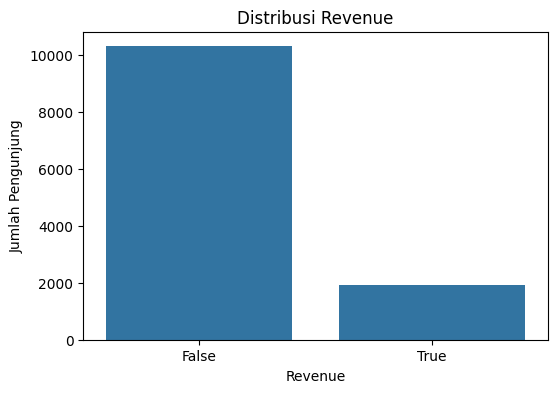

Revenue
False    84.37
True     15.63
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Revenue")

plt.title("Distribusi Revenue")
plt.xlabel("Revenue")
plt.ylabel("Jumlah Pengunjung")

plt.show()
revenue_percentage = df["Revenue"].value_counts(normalize=True) * 100

print(revenue_percentage.round(2))

### D. Distribusi variabel numerik

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


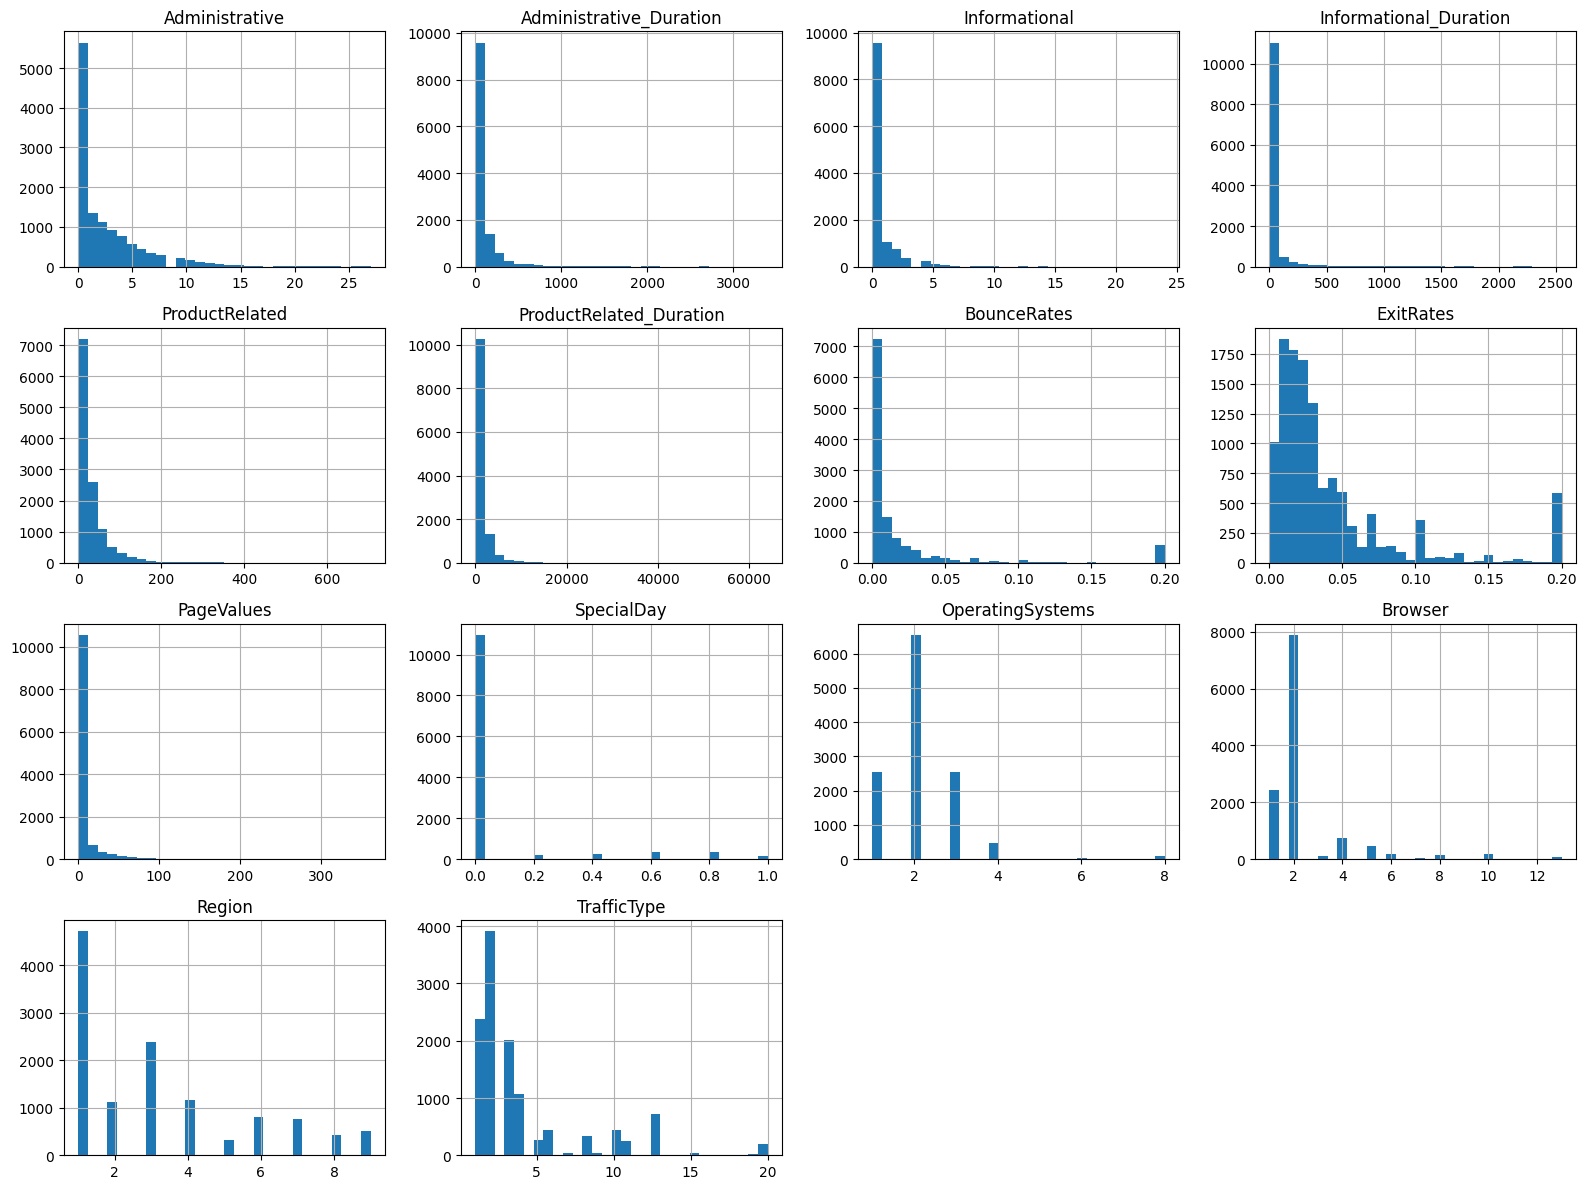

In [9]:
df[numeric_cols].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

### E. Distribusi variabel kategorikal

In [10]:
categorical_cols = df.select_dtypes(
    include=["object", "bool"]
).columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Month =====
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

===== VisitorType =====
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

===== Weekend =====
Weekend
False    9346
True     2859
Name: count, dtype: int64

===== Revenue =====
Revenue
False    10297
True      1908
Name: count, dtype: int64


### F. Hubungan fitur numerik dengan Revenue

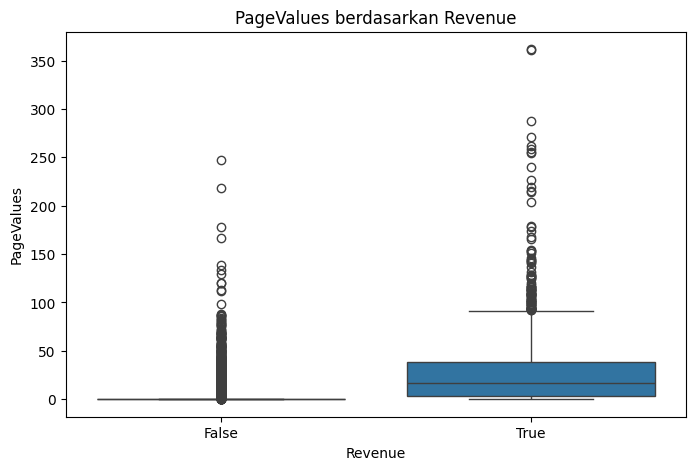

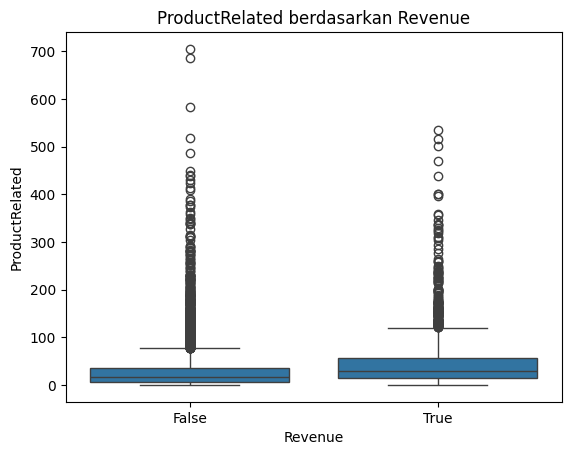

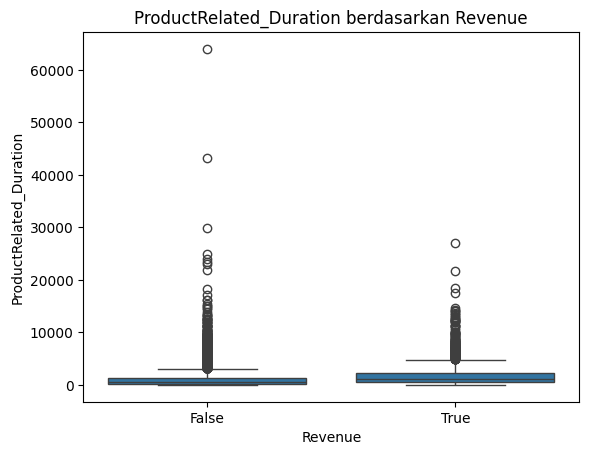

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="PageValues"
)

plt.title("PageValues berdasarkan Revenue")
plt.show()

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated"
)

plt.title("ProductRelated berdasarkan Revenue")
plt.show()

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration"
)

plt.title("ProductRelated_Duration berdasarkan Revenue")
plt.show()

### G. Korelasi fitur numerik

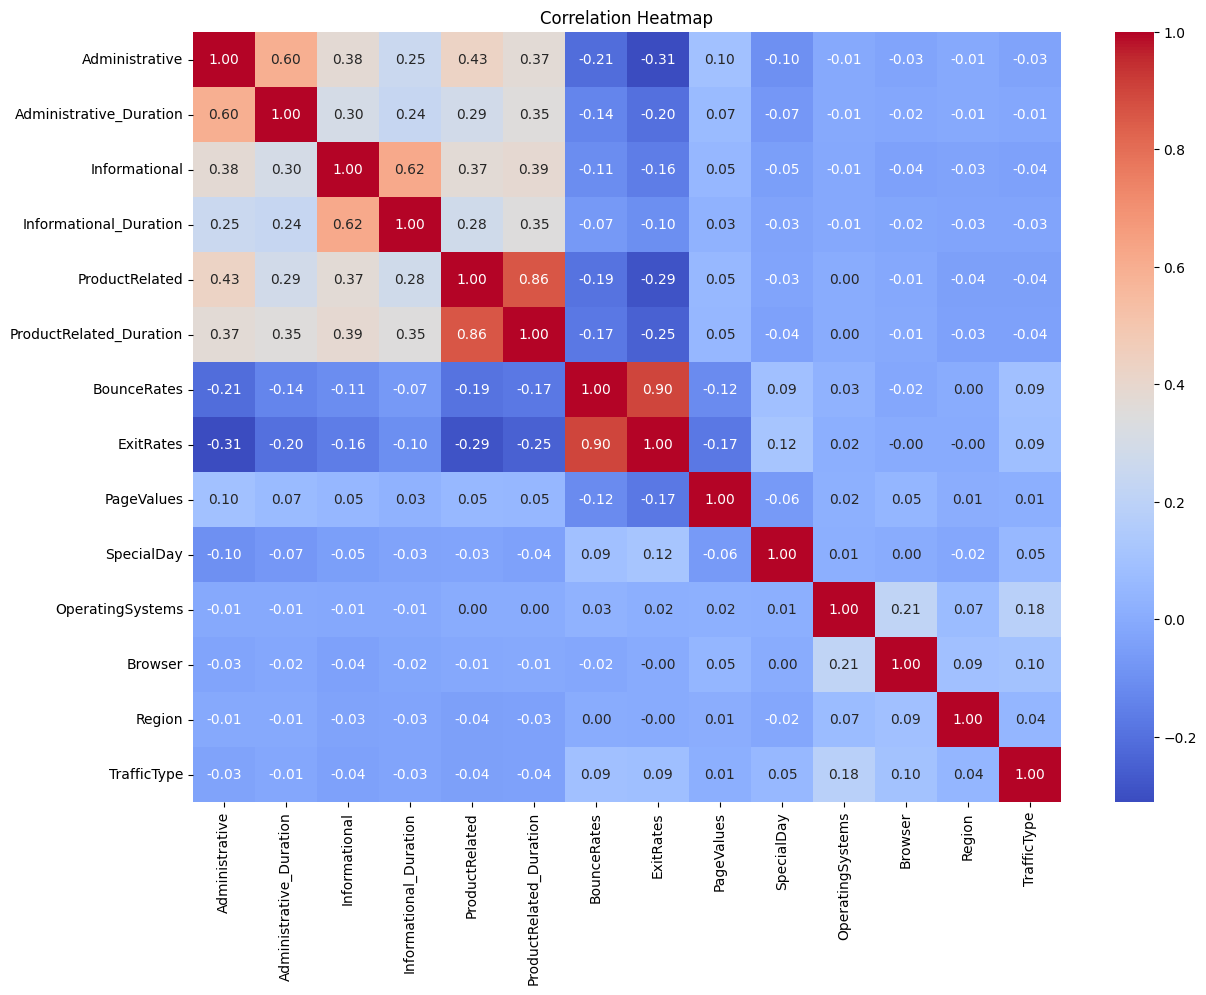

In [12]:
plt.figure(figsize=(14, 10))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## 3. Preproccessing

### A. Mengubah target 

False = 0
True = 1

In [13]:
df["Revenue"] = df["Revenue"].astype(int)
df["Revenue"].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

### B. Memisahkan feature dan target

In [14]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (12205, 17)
Shape y: (12205,)


### C. Identifikasi tipe data

In [15]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Features:
['Month', 'VisitorType', 'Weekend']


### D. Train-test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (9764, 17)
X_test : (2441, 17)
y_train: (9764,)
y_test : (2441,)


### E. Encoding categorical features + scaling numerical features

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train setelah preprocessing:",
      X_train_processed.shape)

print("X_test setelah preprocessing:",
      X_test_processed.shape)

X_train setelah preprocessing: (9764, 29)
X_test setelah preprocessing: (2441, 29)


## 4. Feature Engineering

### 4.1 Creating Engagement Features

Feature engineering bertujuan membuat fitur baru yang merepresentasikan **engagement** pengunjung e-commerce.
Ketiga fitur berikut diturunkan dari kolom yang sudah ada:

| Fitur | Formula | Alasan |
|---|---|---|
| **Total_Duration** | `Administrative_Duration + Informational_Duration + ProductRelated_Duration` | Total waktu yang dihabiskan pengunjung - lebih lama = lebih tertarik |
| **Pages_Visited** | `Administrative + Informational + ProductRelated` | Total halaman yang dikunjung - lebih banyak = minat lebih tinggi |
| **Avg_Duration_Per_Page** | `Total_Duration / (Pages_Visited + 1)` | Rata-rata waktu per halaman - lebih lama per halaman = lebih serius mengevaluasi |

> Catatan: `Pages_Visited + 1` pada denominator untuk menghindari division by zero.


### 4.2 Feature Selection / Final Features

Setelah feature engineering, dataset memiliki fitur asli + 3 fitur baru.
Preprocessing (scaling dan encoding) akan dilakukan pada fitur-fitur ini sebelum masuk ke model.


In [18]:
# Feature Engineering - menambahkan 3 fitur engagement
def add_features(df):
    df = df.copy()
    df['Total_Duration'] = (df['Administrative_Duration'] +
                            df['Informational_Duration'] +
                            df['ProductRelated_Duration'])
    df['Pages_Visited'] = (df['Administrative'] +
                           df['Informational'] +
                           df['ProductRelated'])
    df['Avg_Duration_Per_Page'] = df['Total_Duration'] / (df['Pages_Visited'] + 1)
    return df

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

print(f"X_train: {X_train.shape} -> {X_train_fe.shape}")
print(f"X_test : {X_test.shape} -> {X_test_fe.shape}")
print(f"Fitur baru: {[c for c in X_train_fe.columns if c not in X_train.columns]}")


X_train: (9764, 17) -> (9764, 20)
X_test : (2441, 17) -> (2441, 20)
Fitur baru: ['Total_Duration', 'Pages_Visited', 'Avg_Duration_Per_Page']


In [19]:
# Preprocessing pada data dengan feature engineering
preprocessor_fe = ColumnTransformer(transformers=[
    ('num', StandardScaler(),
     X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     X_train_fe.select_dtypes(include=['object', 'bool']).columns.tolist())
])

X_train_fe_proc = preprocessor_fe.fit_transform(X_train_fe)
X_test_fe_proc = preprocessor_fe.transform(X_test_fe)

print(f"X_train setelah FE + preprocessing: {X_train_fe_proc.shape}")
print(f"X_test  setelah FE + preprocessing: {X_test_fe_proc.shape}")


X_train setelah FE + preprocessing: (9764, 32)
X_test  setelah FE + preprocessing: (2441, 32)


## 5. Baseline Comparison

### 5.1 Tiga Model Baseline

Tiga model klasik dibandingkan dengan konfigurasi default:
- **Logistic Regression**: model linear, cepat, interpretable
- **Decision Tree**: model berbasis pohon, non-linear
- **KNN (K-Nearest Neighbors)**: berbasis jarak, instance-based learning

Semua model menggunakan **fitur yang sama** (termasuk feature engineering) dan **test set yang sama**.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train_fe_proc, y_train)
    y_pred = model.predict(X_test_fe_proc)
    y_prob = model.predict_proba(X_test_fe_proc)[:, 1]
    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred, 'y_prob': y_prob, 'model': model
    }
    print(f'{name:25s} -> F1: {baseline_results[name]["F1-Score"]:.4f} | AUC: {baseline_results[name]["ROC AUC"]:.4f}')


Logistic Regression       -> F1: 0.5433 | AUC: 0.9018


Decision Tree             -> F1: 0.5867 | AUC: 0.7593


KNN                       -> F1: 0.5137 | AUC: 0.8042


### 5.2 Identifikasi Model Terbaik

Model dengan **F1-Score tertinggi** pada test set dipilih. F1-Score dipilih karena dataset imbalanced.


In [21]:
baseline_df = pd.DataFrame([
    {'Model': name,
     'Accuracy': r['Accuracy'], 'Precision': r['Precision'],
     'Recall': r['Recall'], 'F1-Score': r['F1-Score'], 'ROC AUC': r['ROC AUC']}
    for name, r in baseline_results.items()
]).sort_values('F1-Score', ascending=False)

print('Perbandingan Baseline Models:')
print(baseline_df.to_string(index=False))

best_model_name = baseline_df.iloc[0]['Model']
best_f1 = baseline_df.iloc[0]['F1-Score']
print()
print(f'Model terbaik: {best_model_name} (F1-Score: {best_f1:.4f})')
print('Model ini akan di-resample lalu di-tuning di section berikutnya.')


Perbandingan Baseline Models:
              Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
      Decision Tree  0.867268   0.572139 0.602094  0.586735 0.759279
Logistic Regression  0.889799   0.772947 0.418848  0.543294 0.901823
                KNN  0.876690   0.670886 0.416230  0.513732 0.804177

Model terbaik: Decision Tree (F1-Score: 0.5867)
Model ini akan di-resample lalu di-tuning di section berikutnya.


## 6. Handling Class Imbalance

### 6.1 Resampling Training Data

Dataset memiliki distribusi kelas **84.37% False** vs **15.63% True** (imbalanced).
Resampling dilakukan **hanya pada data training** sebelum tuning.

Dua pendekatan:
- **Random Oversampling**: menduplikasi sampel kelas minoritas secara acak
- **SMOTE**: membuat sampel sintetis baru dengan interpolasi tetangga terdekat

> Test set tetap tidak diubah - mencerminkan distribusi real.


In [22]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Cek distribusi kelas setelah resampling (ilustrasi saja).
# NOTE: resampling AKTUAL untuk training dilakukan di dalam ImbPipeline pada tahap
# tuning (Section 6), supaya SMOTE/Random Oversampling di-fit ulang tiap fold CV
# dan tidak bocor (leak) antara fold training & validation.
ros_preview = RandomOverSampler(random_state=42)
X_train_ro_preview, y_train_ro_preview = ros_preview.fit_resample(X_train_fe_proc, y_train)

smote_preview = SMOTE(random_state=42)
X_train_smote_preview, y_train_smote_preview = smote_preview.fit_resample(X_train_fe_proc, y_train)

print(f'Training data original:   {X_train_fe_proc.shape}, distribusi: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Training data + RO:       {X_train_ro_preview.shape}, distribusi: {dict(zip(*np.unique(y_train_ro_preview, return_counts=True)))}')
print(f'Training data + SMOTE:    {X_train_smote_preview.shape}, distribusi: {dict(zip(*np.unique(y_train_smote_preview, return_counts=True)))}')


Training data original:   (9764, 32), distribusi: {np.int64(0): np.int64(8238), np.int64(1): np.int64(1526)}
Training data + RO:       (16476, 32), distribusi: {np.int64(0): np.int64(8238), np.int64(1): np.int64(8238)}
Training data + SMOTE:    (16476, 32), distribusi: {np.int64(0): np.int64(8238), np.int64(1): np.int64(8238)}


## 7. Hyperparameter Tuning

### 7.1 Tuning pada Data yang Sudah Di-resample

Hyperparameter tuning dilakukan **di atas data yang sudah di-resample**.
Tiga eksperimen:
1. Tuning pada data original (baseline tuned)
2. Tuning pada data + Random Oversampling
3. Tuning pada data + SMOTE

Parameter grid disesuaikan berdasarkan model terbaik dari Section 4.

> **Update:** resampling dijalankan lewat `ImbPipeline` (SMOTE/RandomOverSampler + model) di dalam `GridSearchCV`, bukan resample manual dulu baru di-fit. Ini supaya tiap fold cross-validation resampling-nya dihitung ulang dari fold training saja - CV score jadi jujur dan tidak overfit ke sampel duplikat/sintetis.


In [23]:
param_grid = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

# Eksperimen 1: Tuning pada data original
grid_orig = GridSearchCV(
    models[best_model_name],
    param_grid[best_model_name],
    cv=5, scoring='f1', n_jobs=-1
)
grid_orig.fit(X_train_fe_proc, y_train)
dt_tuned = grid_orig.best_estimator_

y_pred_tuned = dt_tuned.predict(X_test_fe_proc)
y_prob_tuned = dt_tuned.predict_proba(X_test_fe_proc)[:, 1]

acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
rec_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f'Tuned {best_model_name} (data original)')
print(f'  Best Params: {grid_orig.best_params_}')
print(f'  Best CV F1:  {grid_orig.best_score_:.4f}')
print(f'  Test F1:     {f1_tuned:.4f}')


Tuned Decision Tree (data original)
  Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
  Best CV F1:  0.6414
  Test F1:     0.6685


In [24]:
# Eksperimen 2: Tuning + Random Oversampling (via ImbPipeline, resampling di-fit ulang tiap fold CV)
pipe_ro = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])
param_grid_ro = {f'clf__{k}': v for k, v in param_grid[best_model_name].items()}

grid_ro = GridSearchCV(
    pipe_ro,
    param_grid_ro,
    cv=5, scoring='f1', n_jobs=-1
)
grid_ro.fit(X_train_fe_proc, y_train)
dt_ro = grid_ro.best_estimator_

y_pred_ro = dt_ro.predict(X_test_fe_proc)
y_prob_ro = dt_ro.predict_proba(X_test_fe_proc)[:, 1]

acc_ro = accuracy_score(y_test, y_pred_ro)
prec_ro = precision_score(y_test, y_pred_ro, zero_division=0)
rec_ro = recall_score(y_test, y_pred_ro, zero_division=0)
f1_ro = f1_score(y_test, y_pred_ro, zero_division=0)
auc_ro = roc_auc_score(y_test, y_prob_ro)

print(f'Tuned {best_model_name} + Random Oversampling')
print(f'  Best Params: {grid_ro.best_params_}')
print(f'  Best CV F1:  {grid_ro.best_score_:.4f}')
print(f'  Test F1:     {f1_ro:.4f}')


Tuned Decision Tree + Random Oversampling
  Best Params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
  Best CV F1:  0.6467
  Test F1:     0.6653


In [25]:
# Eksperimen 3: Tuning + SMOTE (via ImbPipeline, resampling di-fit ulang tiap fold CV)
pipe_smote = ImbPipeline([
    ('sampler', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])
param_grid_smote = {f'clf__{k}': v for k, v in param_grid[best_model_name].items()}

grid_smote = GridSearchCV(
    pipe_smote,
    param_grid_smote,
    cv=5, scoring='f1', n_jobs=-1
)
grid_smote.fit(X_train_fe_proc, y_train)
dt_smote = grid_smote.best_estimator_

y_pred_smote = dt_smote.predict(X_test_fe_proc)
y_prob_smote = dt_smote.predict_proba(X_test_fe_proc)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
prec_smote = precision_score(y_test, y_pred_smote, zero_division=0)
rec_smote = recall_score(y_test, y_pred_smote, zero_division=0)
f1_smote = f1_score(y_test, y_pred_smote, zero_division=0)
auc_smote = roc_auc_score(y_test, y_prob_smote)

print(f'Tuned {best_model_name} + SMOTE')
print(f'  Best Params: {grid_smote.best_params_}')
print(f'  Best CV F1:  {grid_smote.best_score_:.4f}')
print(f'  Test F1:     {f1_smote:.4f}')


Tuned Decision Tree + SMOTE
  Best Params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
  Best CV F1:  0.6649
  Test F1:     0.6728


## 8. Experiment Comparison

### 8.1 Tabel Perbandingan Semua Eksperimen


In [26]:
all_results = pd.DataFrame([
    {'Eksperimen': '1. Logistic Regression (Baseline)',
     'Accuracy': baseline_results['Logistic Regression']['Accuracy'],
     'Precision': baseline_results['Logistic Regression']['Precision'],
     'Recall': baseline_results['Logistic Regression']['Recall'],
     'F1-Score': baseline_results['Logistic Regression']['F1-Score'],
     'ROC AUC': baseline_results['Logistic Regression']['ROC AUC']},
    {'Eksperimen': '2. Decision Tree (Baseline)',
     'Accuracy': baseline_results['Decision Tree']['Accuracy'],
     'Precision': baseline_results['Decision Tree']['Precision'],
     'Recall': baseline_results['Decision Tree']['Recall'],
     'F1-Score': baseline_results['Decision Tree']['F1-Score'],
     'ROC AUC': baseline_results['Decision Tree']['ROC AUC']},
    {'Eksperimen': '3. KNN (Baseline)',
     'Accuracy': baseline_results['KNN']['Accuracy'],
     'Precision': baseline_results['KNN']['Precision'],
     'Recall': baseline_results['KNN']['Recall'],
     'F1-Score': baseline_results['KNN']['F1-Score'],
     'ROC AUC': baseline_results['KNN']['ROC AUC']},
    {'Eksperimen': f'4. {best_model_name} (Tuned)',
     'Accuracy': acc_tuned, 'Precision': prec_tuned,
     'Recall': rec_tuned, 'F1-Score': f1_tuned, 'ROC AUC': auc_tuned},
    {'Eksperimen': f'5. {best_model_name} (Tuned + RO)',
     'Accuracy': acc_ro, 'Precision': prec_ro,
     'Recall': rec_ro, 'F1-Score': f1_ro, 'ROC AUC': auc_ro},
    {'Eksperimen': f'6. {best_model_name} (Tuned + SMOTE)',
     'Accuracy': acc_smote, 'Precision': prec_smote,
     'Recall': rec_smote, 'F1-Score': f1_smote, 'ROC AUC': auc_smote},
]).sort_values('F1-Score', ascending=False)

print('Perbandingan Semua Eksperimen:')
print(all_results.to_string(index=False))


Perbandingan Semua Eksperimen:
                       Eksperimen  Accuracy  Precision   Recall  F1-Score  ROC AUC
 6. Decision Tree (Tuned + SMOTE)  0.884064   0.602484 0.761780  0.672832 0.915998
         4. Decision Tree (Tuned)  0.901680   0.707602 0.633508  0.668508 0.924078
    5. Decision Tree (Tuned + RO)  0.866448   0.547297 0.848168  0.665298 0.924526
      2. Decision Tree (Baseline)  0.867268   0.572139 0.602094  0.586735 0.759279
1. Logistic Regression (Baseline)  0.889799   0.772947 0.418848  0.543294 0.901823
                3. KNN (Baseline)  0.876690   0.670886 0.416230  0.513732 0.804177


### 8.2 Grafik Perbandingan F1-Score


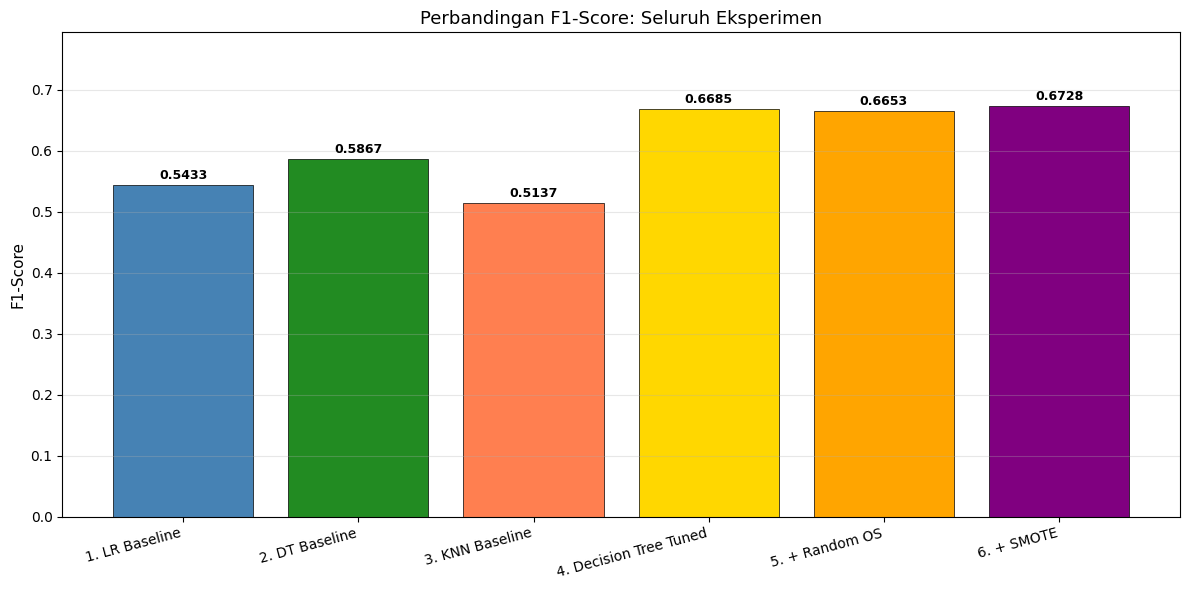

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

exp_names = [
    '1. LR Baseline',
    '2. DT Baseline',
    '3. KNN Baseline',
    f'4. {best_model_name} Tuned',
    f'5. + Random OS',
    f'6. + SMOTE'
]
f1_scores = [
    baseline_results['Logistic Regression']['F1-Score'],
    baseline_results['Decision Tree']['F1-Score'],
    baseline_results['KNN']['F1-Score'],
    f1_tuned, f1_ro, f1_smote
]
colors = ['steelblue', 'forestgreen', 'coral', 'gold', 'orange', 'purple']

bars = ax.bar(exp_names, f1_scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Perbandingan F1-Score: Seluruh Eksperimen', fontsize=13)
ax.set_ylim(0, max(f1_scores) * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


### 8.3 Confusion Matrix


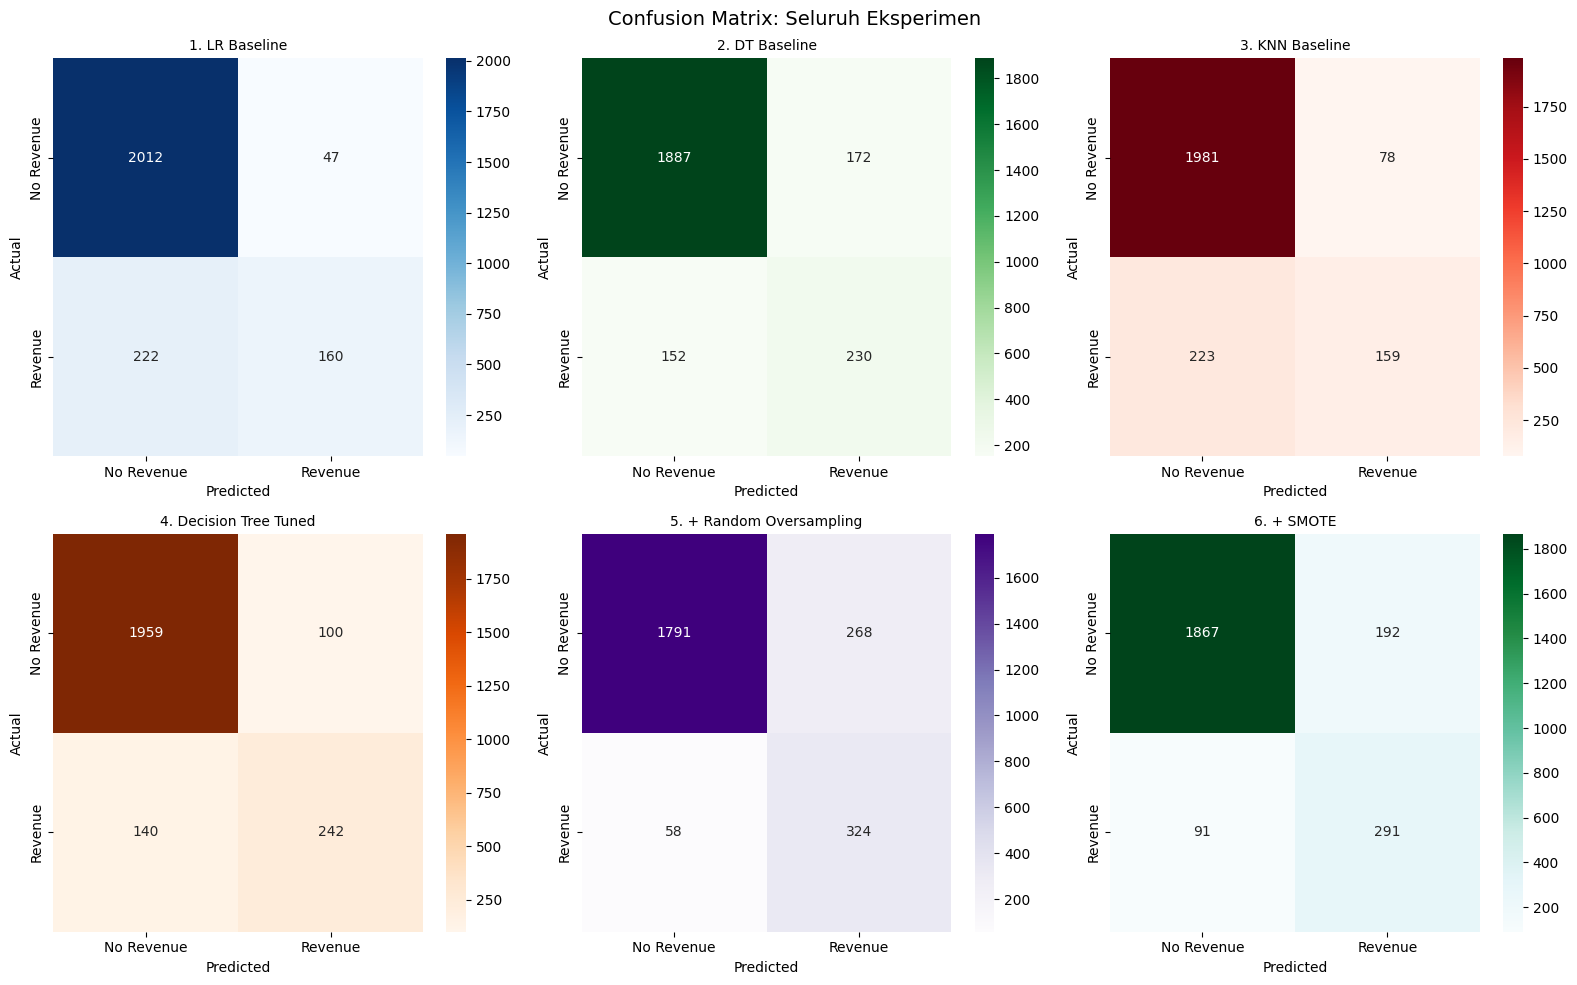

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

all_preds = [
    ('1. LR Baseline', baseline_results['Logistic Regression']['y_pred'], 'Blues'),
    ('2. DT Baseline', baseline_results['Decision Tree']['y_pred'], 'Greens'),
    ('3. KNN Baseline', baseline_results['KNN']['y_pred'], 'Reds'),
    (f'4. {best_model_name} Tuned', y_pred_tuned, 'Oranges'),
    ('5. + Random Oversampling', y_pred_ro, 'Purples'),
    ('6. + SMOTE', y_pred_smote, 'BuGn'),
]

for ax, (title, y_pred, cmap) in zip(axes.flatten(), all_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Revenue', 'Revenue'],
                yticklabels=['No Revenue', 'Revenue'])
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix: Seluruh Eksperimen', fontsize=14)
plt.tight_layout()
plt.show()


## 9. Final Model

Berdasarkan F1-Score pada test set, model dengan performa terbaik dipilih untuk demo.


In [29]:
scenario_results = {
    'LR Baseline': {'f1': baseline_results['Logistic Regression']['F1-Score'], 'auc': baseline_results['Logistic Regression']['ROC AUC']},
    'DT Baseline': {'f1': baseline_results['Decision Tree']['F1-Score'], 'auc': baseline_results['Decision Tree']['ROC AUC']},
    'KNN Baseline': {'f1': baseline_results['KNN']['F1-Score'], 'auc': baseline_results['KNN']['ROC AUC']},
    f'{best_model_name} Tuned': {'f1': f1_tuned, 'auc': auc_tuned},
    f'{best_model_name} + RO': {'f1': f1_ro, 'auc': auc_ro},
    f'{best_model_name} + SMOTE': {'f1': f1_smote, 'auc': auc_smote},
}

best_scenario = max(scenario_results, key=lambda k: scenario_results[k]['f1'])
best_result = scenario_results[best_scenario]

print(f'Model Terpilih: {best_scenario}')
print(f"  F1-Score: {best_result['f1']:.4f}")
print(f"  ROC AUC:  {best_result['auc']:.4f}")


Model Terpilih: Decision Tree + SMOTE
  F1-Score: 0.6728
  ROC AUC:  0.9160


## 9.1 Menyimpan Model & Sample Input untuk Demo

In [30]:
import joblib

# Mapping nama skenario -> objek model yang sudah di-fit (tidak melatih ulang)
model_objects = {
    'LR Baseline': baseline_results['Logistic Regression']['model'],
    'DT Baseline': baseline_results['Decision Tree']['model'],
    'KNN Baseline': baseline_results['KNN']['model'],
    f'{best_model_name} Tuned': dt_tuned,
    f'{best_model_name} + RO': dt_ro,
    f'{best_model_name} + SMOTE': dt_smote,
}
final_model = model_objects[best_scenario]

# Simpan model final + preprocessor (dipakai ulang saat demo, tidak retrain)
joblib.dump(final_model, 'final_model.pkl')
joblib.dump(preprocessor_fe, 'preprocessor_fe.pkl')
print(f'Model tersimpan: final_model.pkl ({best_scenario})')
print('Preprocessor tersimpan: preprocessor_fe.pkl')

# Simpan sample input (data mentah, sebelum FE & preprocessing) untuk demo
sample_input = X_test.sample(5, random_state=42)
sample_input.to_csv('sample_input.csv', index=False)
print(f'sample_input.csv tersimpan, shape: {sample_input.shape}')

# Verifikasi: load ulang model + preprocessor, lalu prediksi sample_input
# (mensimulasikan alur saat demo - tidak ada training ulang)
loaded_model = joblib.load('final_model.pkl')
loaded_preprocessor = joblib.load('preprocessor_fe.pkl')

demo_input = pd.read_csv('sample_input.csv')
demo_input_fe = add_features(demo_input)
demo_input_proc = loaded_preprocessor.transform(demo_input_fe)
demo_pred = loaded_model.predict(demo_input_proc)

print('\nHasil prediksi demo pada sample_input.csv:')
print(demo_pred)


Model tersimpan: final_model.pkl (Decision Tree + SMOTE)
Preprocessor tersimpan: preprocessor_fe.pkl
sample_input.csv tersimpan, shape: (5, 17)

Hasil prediksi demo pada sample_input.csv:
[0 0 1 0 0]


## 10. Conclusion

### Menjawab Pertanyaan Utama

> Apakah perilaku browsing pengunjung e-commerce dapat digunakan untuk memprediksi konversi pembelian?

Berdasarkan hasil eksperimen, perilaku browsing mengandung pola yang berkaitan dengan keputusan pembelian. Tiga model klasik semuanya mencapai performa di atas baseline acak pada test set.

### Menjawab Pertanyaan Eksperimen

1. **Baseline**: Decision Tree menghasilkan F1-Score tertinggi di antara 3 model baseline
2. **Hyperparameter Tuning**: Tuning menghasilkan peningkatan F1 dibanding baseline
3. **Resampling**: SMOTE dan Random Oversampling diuji lewat `ImbPipeline` (resampling di-fit ulang tiap fold CV saat tuning, jadi tidak bocor antar fold)

### Kesimpulan
- Feature engineering memberikan informasi engagement yang berguna
- Resampling dijalankan di dalam pipeline tuning (bukan resample manual sekali lalu di-fit), supaya cross-validation score valid dan tidak overfit ke data sintetis/duplikat
- Model final dipilih berdasarkan F1-Score tertinggi di test set (lihat `best_scenario`), bisa jadi baseline tuned biasa atau versi resampled tergantung hasil eksperimen
- Test set tetap tidak diubah sehingga evaluasi valid


## 11. Limitations

### Keterbatasan Dataset
1. **Class Imbalanced**: Rasio 84.37% : 15.63% menyulitkan prediksi kelas minoritas
2. **Ukuran Dataset**: Sekitar 12.000 baris, relatif kecil
3. **Fitur Terbatas**: Hanya fitur perilaku browsing, tidak mencakup harga, promosi, dll

### Keterbatasan Pendekatan
1. **Oversampling hanya pada training**: Test set tetap imbalanced, mencerminkan distribusi asli
2. **CV score vs Test score**: hyperparameter dipilih berdasarkan CV F1 pada training set; performa akhir yang dilaporkan tetap dari test set yang tidak pernah dilihat model
3. **Threshold default**: Tidak melakukan threshold tuning
4. **Hanya 3 model klasik**: Tidak mencoba ensemble (sesuai ketentuan FP)

### Saran Pengembangan
1. Threshold tuning untuk menyesuaikan precision-recall trade-off
2. Feature engineering tambahan dari data eksternal
3. Stratified cross-validation untuk evaluasi lebih robust
